# Retail Sales Analysis

## Exploratory Data Analysis (EDA)

### Business Objective

The objective of this phase is to explore the cleaned retail dataset in order to identify patterns, trends, relationships, and business opportunities through descriptive statistics and data visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.options.display.float_format = "{:.2f}".format

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

df = pd.read_csv("../data/processed/superstore_clean.csv")

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

## Sales Overview

In [ ]:
sales_kpis = pd.DataFrame({
    "Metric":[
        "Total Sales",
        "Total Profit",
        "Total Orders",
        "Average Sales",
        "Average Profit"
    ],
    "Value":[
        df["Sales"].sum(),
        df["Profit"].sum(),
        df["Order ID"].nunique(),
        df["Sales"].mean(),
        df["Profit"].mean()
    ]
})

sales_kpis

,Metric,Value
0,Total Sales,2288271.49
1,Total Profit,284152.04
2,Total Orders,5003.00
3,Average Sales,229.22
4,Average Profit,28.46


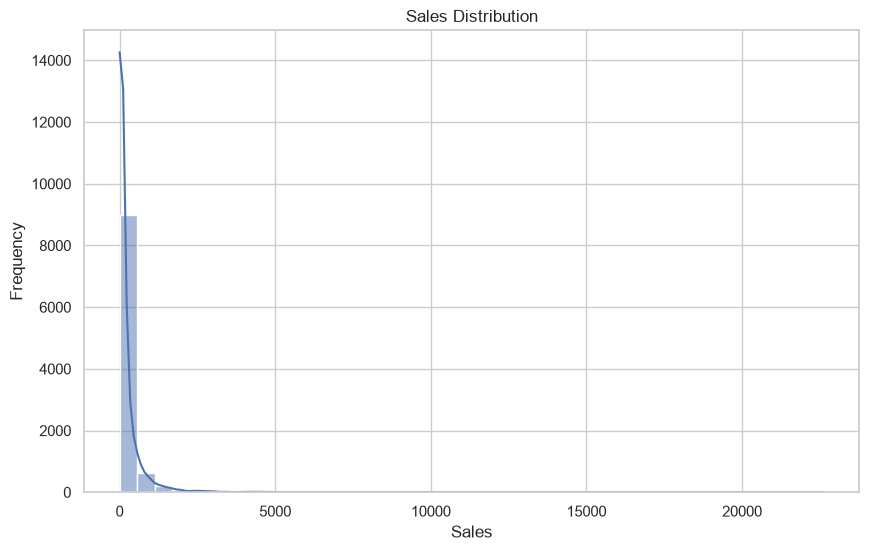

In [4]:
#Sales distribution
plt.figure(figsize=(10,6))
sns.histplot(df["Sales"], bins=40, kde=True)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

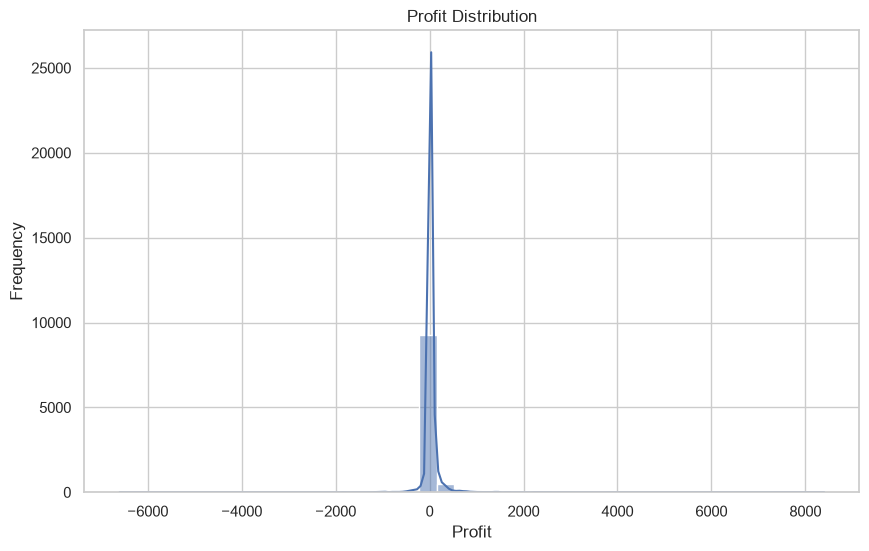

In [ ]:
#Profit distribution
plt.figure(figsize=(10,6))
sns.histplot(df["Profit"], bins=40, kde=True)
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

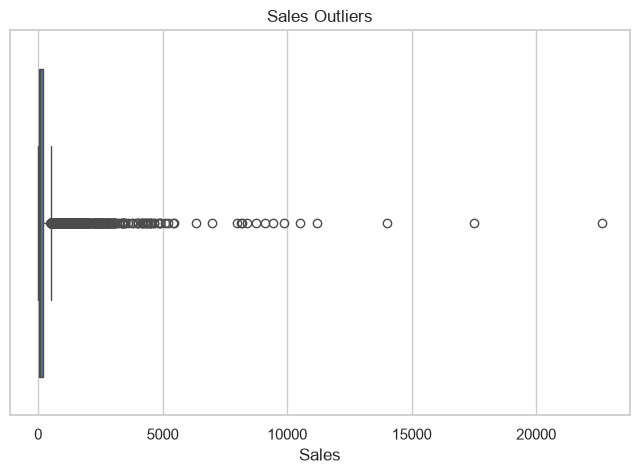

In [6]:
#Sales boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Sales"])
plt.title("Sales Outliers")
plt.show()

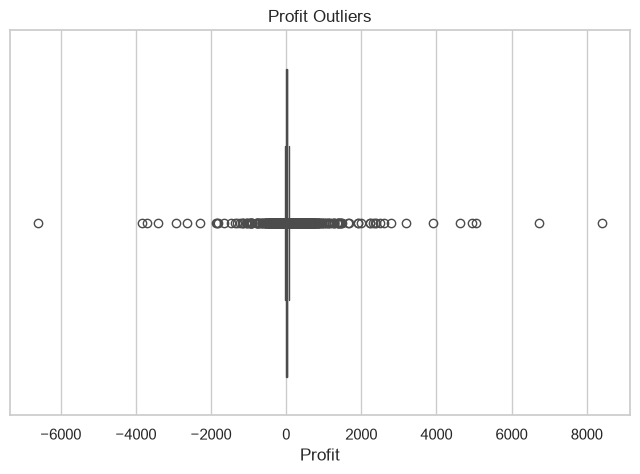

In [ ]:
#Profit boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Profit"])
plt.title("Profit Outliers")
plt.show()

### Business Insight

The sales and profit distributions are highly skewed, indicating that a relatively small number of transactions account for a large proportion of revenue. Outliers are expected in retail environments and will be further investigated.

## Time Analysis

In [8]:
monthly_sales = (
    df.groupby(["Year","Month Name"])["Sales"]
      .sum()
      .reset_index()
)

monthly_sales

,Year,Month Name,Sales
0,2015,April,28295.35
1,2015,August,27909.47
2,2015,December,69545.62
3,2015,February,4519.89
4,2015,January,14236.90
5,2015,July,33946.39
6,2015,June,34595.13
7,2015,March,55691.01
8,2015,May,23648.29
9,2015,November,78628.72


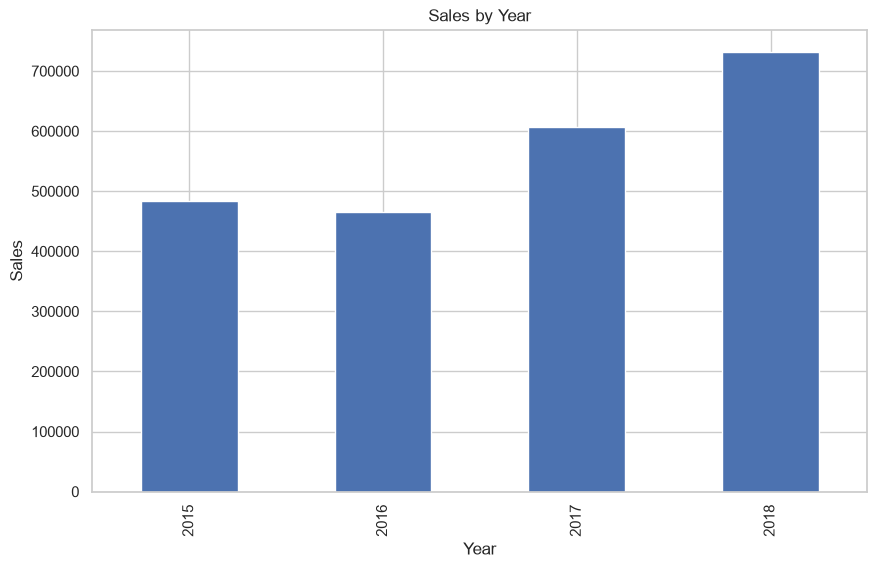

In [ ]:
#Sales by year
sales_year=df.groupby("Year")["Sales"].sum()

sales_year.plot(kind="bar")

plt.title("Sales by Year")

plt.ylabel("Sales")

plt.show()

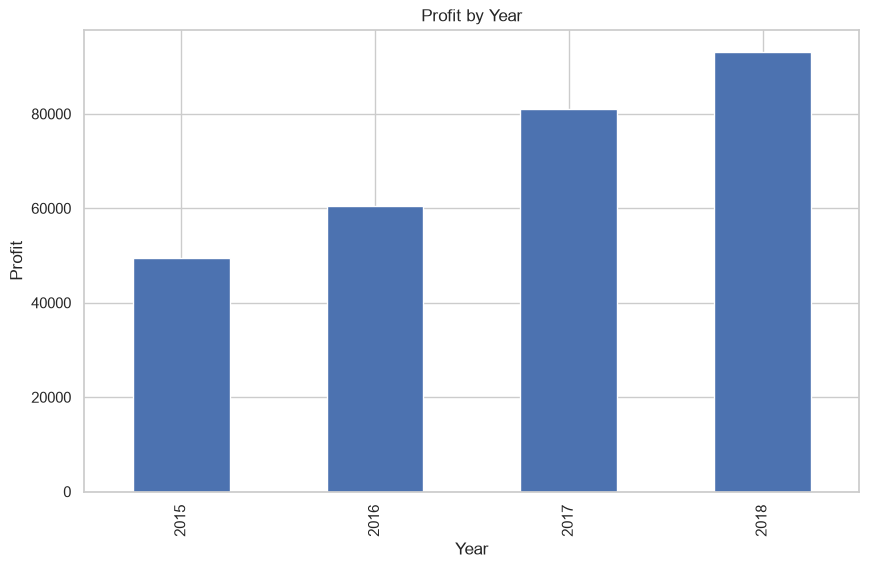

In [ ]:
#Profit by year
profit_year=df.groupby("Year")["Profit"].sum()

profit_year.plot(kind="bar")

plt.title("Profit by Year")

plt.ylabel("Profit")

plt.show()

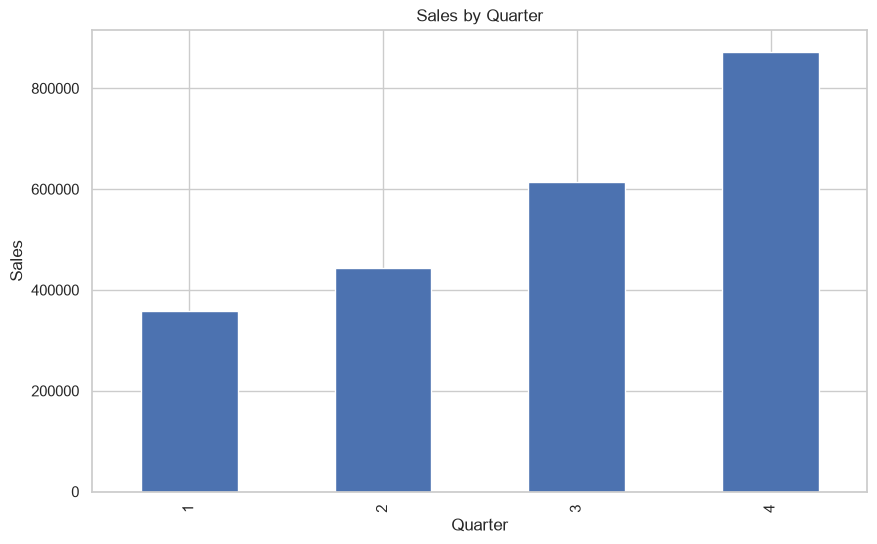

In [ ]:
#Sales by quarter
quarter_sales=df.groupby("Quarter")["Sales"].sum()

quarter_sales.plot(kind="bar")

plt.title("Sales by Quarter")

plt.ylabel("Sales")

plt.show()

### Business Insight

Sales exhibit temporal variation across years and quarters, suggesting seasonal behavior that should be considered when planning inventory and marketing campaigns.

## Category Analysis

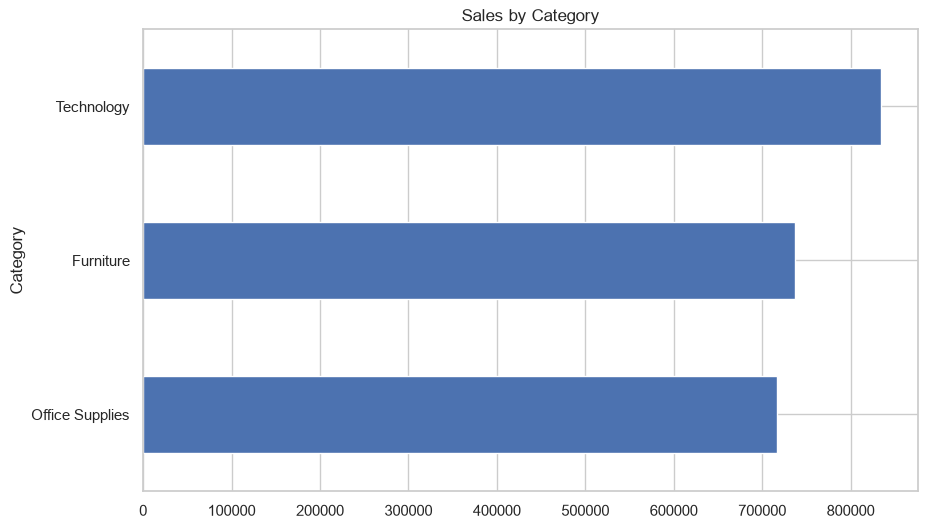

In [ ]:
#Categorical sales
category_sales=df.groupby("Category")["Sales"].sum().sort_values()

category_sales.plot(kind="barh")

plt.title("Sales by Category")

plt.show()

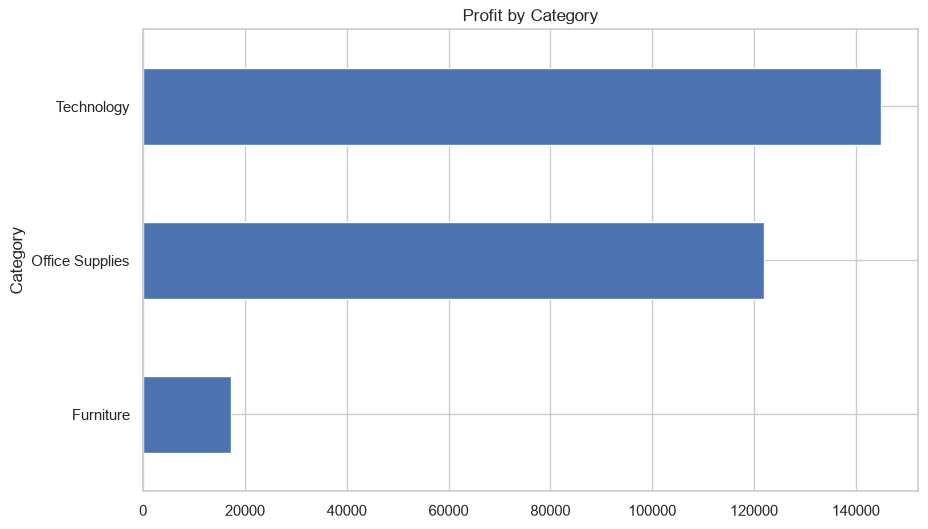

In [ ]:
#Categorical profit
category_profit=df.groupby("Category")["Profit"].sum().sort_values()

category_profit.plot(kind="barh")

plt.title("Profit by Category")

plt.show()

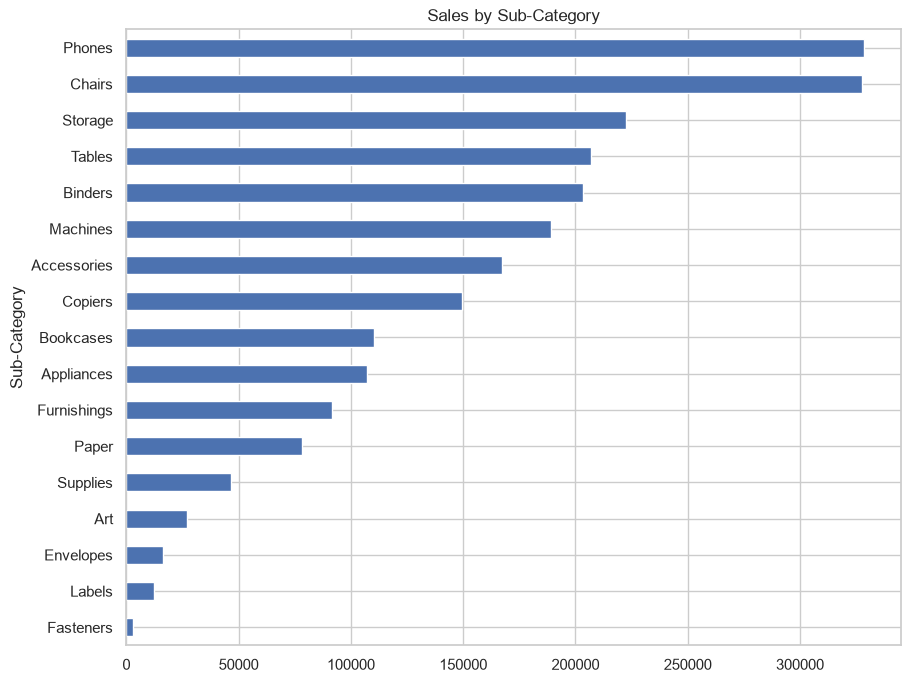

In [ ]:
#Sales by Sub-Category
subcategory=df.groupby("Sub-Category")["Sales"].sum().sort_values()

subcategory.plot(kind="barh",figsize=(10,8))

plt.title("Sales by Sub-Category")

plt.show()

## Regional Analysis

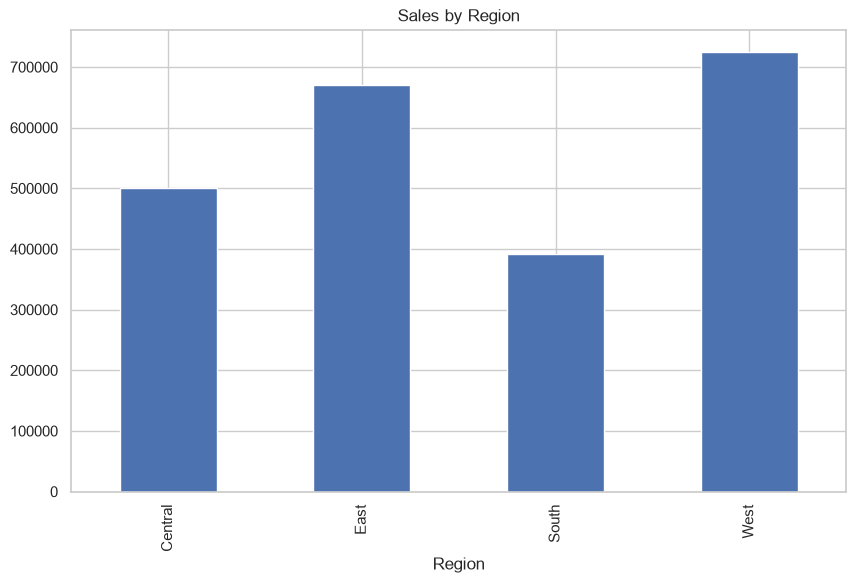

In [ ]:
#Sales by region
region_sales=df.groupby("Region")["Sales"].sum()

region_sales.plot(kind="bar")

plt.title("Sales by Region")

plt.show()

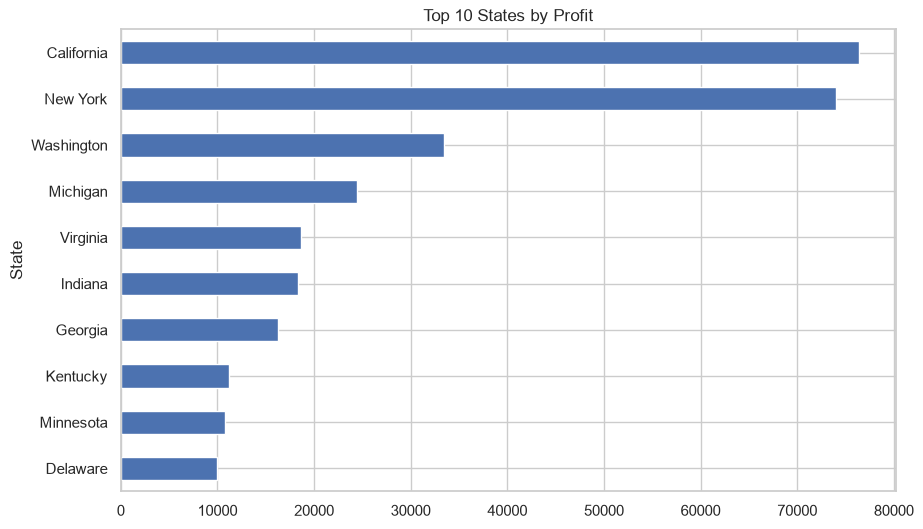

In [ ]:
#States by it's profit
state_profit=(df.groupby("State")["Profit"]
                .sum()
                .sort_values()
                .tail(10))

state_profit.plot(kind="barh")

plt.title("Top 10 States by Profit")

plt.show()

## Customer Analysis

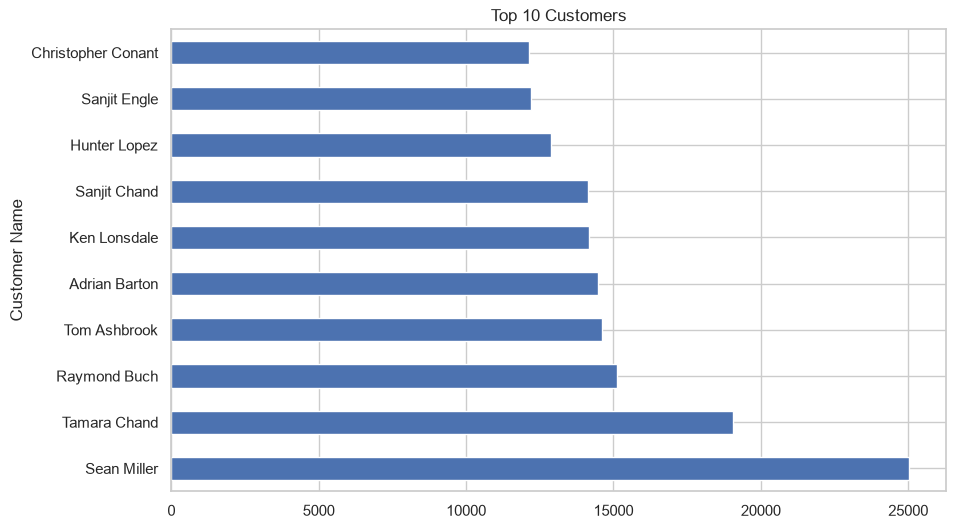

In [ ]:
#Top 10 customres
top_customers=(df.groupby("Customer Name")["Sales"]
                 .sum()
                 .sort_values(ascending=False)
                 .head(10))

top_customers.plot(kind="barh")

plt.title("Top 10 Customers")

plt.show()

## Product Analysis

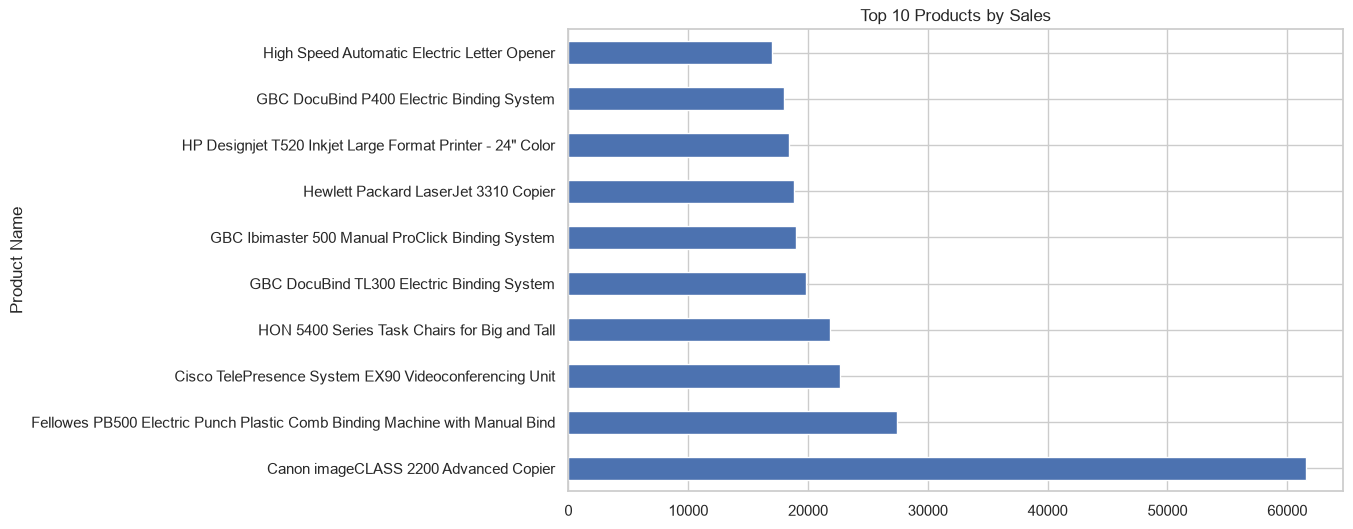

In [ ]:
#Top 10 most sold productos
top_products=(df.groupby("Product Name")["Sales"]
                .sum()
                .sort_values(ascending=False)
                .head(10))

top_products.plot(kind="barh")

plt.title("Top 10 Products by Sales")

plt.show()

## Discount Analysis

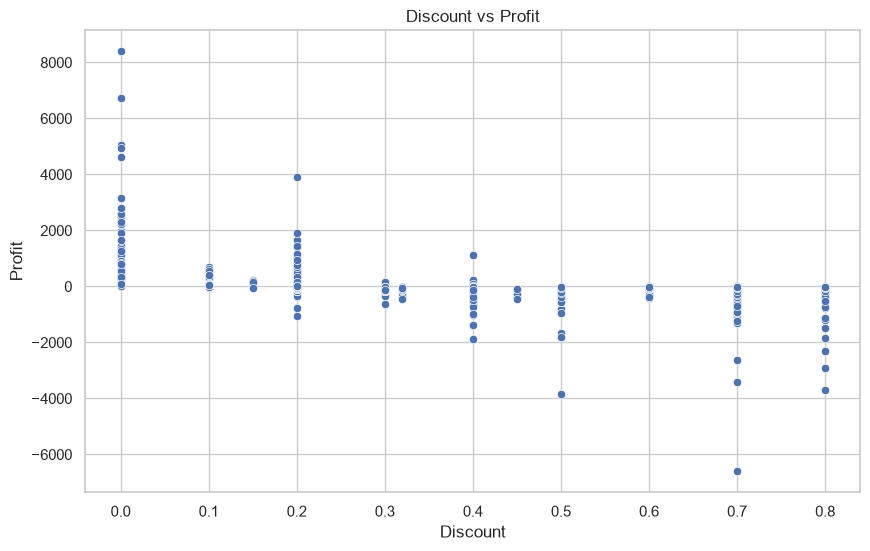

In [ ]:
#Discount against profit
plt.figure(figsize=(10,6))

sns.scatterplot(data=df,
                x="Discount",
                y="Profit")

plt.title("Discount vs Profit")

plt.show()

## Correlation Analysis

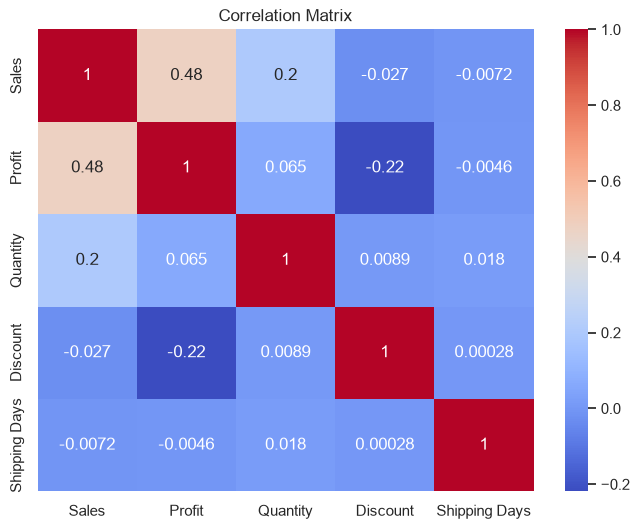

In [ ]:
#Correlation matrix
corr=df[["Sales","Profit","Quantity","Discount","Shipping Days"]].corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

In [21]:
df.to_csv("../data/processed/superstore_eda.csv",index=False)

## EDA Summary

-The exploratory analysis revealed significant variation in sales, profitability, customer behavior, and regional performance.

-Several high-value customers and products contribute disproportionately to total revenue.

-Discount levels appear to influence profitability, while seasonal patterns suggest opportunities for improving inventory planning and marketing strategies.

-The findings obtained during this phase will serve as the basis for the Power BI dashboard developed in the next stage.